# Tutorial 2: Economic Criteria Data Entry and AHP Ranking

This notebook calculates the AHP ranking of MSW-to-energy alternatives using only the **Economic** criterion.

The economic indicators used are:

1. CAPEX
2. OPEX
3. LCOE

All three indicators are treated as **cost criteria**, meaning lower values are preferred.


In [6]:
import numpy as np
import pandas as pd

## 1. Define alternatives

The alternatives must use the same names as in the hierarchy notebook.

In [7]:
alternatives = [
    "INC-E",
    "INC-H",
    "AD",
    "PYR",
    "GAS",
    "HTC",
    "Composting",
    "INC-E-CCS 85%",
    "INC-E-CCS 95%",
    "INC-H-CCS- 85%",
    "INC-H-CCS- 95%",
]

alternatives

['INC-E',
 'INC-H',
 'AD',
 'PYR',
 'GAS',
 'HTC',
 'Composting',
 'INC-E-CCS 85%',
 'INC-E-CCS 95%',
 'INC-H-CCS- 85%',
 'INC-H-CCS- 95%']

## 2. Enter economic data

The table below stores CAPEX, OPEX, and LCOE values for each alternative.

Because these are economic cost indicators, lower values are better.

In [8]:
economic_data = pd.DataFrame({
    "Alternative": alternatives,

    "CAPEX": [
        591,
        428,
        245,
        492,
        604.5,
        314,
        139,
        596.5,
        597.5,
        430,
        434,
    ],

    "OPEX": [
        33,
        30,
        38.5,
        49.5,
        61.5,
        35.5,
        12.5,
        76,
        77.5,
        72,
        73,
    ],

    "LCOE": [
        0.036794,
        0.007615,
        0.029,
        0.020301,
        0.016986,
        0.008752,
        np.nan,
        0.067190,
        0.095444,
        0.014841,
        0.016188,
    ],
})

economic_data

,Alternative,CAPEX,OPEX,LCOE
0,INC-E,591.0,33.0,0.036794
1,INC-H,428.0,30.0,0.007615
2,AD,245.0,38.5,0.029000
3,PYR,492.0,49.5,0.020301
4,GAS,604.5,61.5,0.016986
5,HTC,314.0,35.5,0.008752
6,Composting,139.0,12.5,NaN
7,INC-E-CCS 85%,596.5,76.0,0.067190
8,INC-E-CCS 95%,597.5,77.5,0.095444
9,INC-H-CCS- 85%,430.0,72.0,0.014841


## 3. Define AHP solver functions

The AHP solver calculates:

- local priority weights,
- lambda max,
- consistency index,
- consistency ratio.

In [9]:
SAATY_RI = {
    1: 0.00,
    2: 0.00,
    3: 0.58,
    4: 0.90,
    5: 1.12,
    6: 1.24,
    7: 1.32,
    8: 1.41,
    9: 1.45,
    10: 1.49,
    11: 1.51,
    12: 1.48,
    13: 1.56,
    14: 1.57,
    15: 1.59,
}


def ahp_eigenvector(matrix):
    values, vectors = np.linalg.eig(matrix)

    index = np.argmax(values.real)

    weights = np.abs(vectors[:, index].real)
    weights = weights / weights.sum()

    lambda_max = values[index].real

    return weights, lambda_max


def ahp_consistency(matrix):
    n = matrix.shape[0]

    weights, lambda_max = ahp_eigenvector(matrix)

    CI = (lambda_max - n) / (n - 1) if n > 1 else 0
    RI = SAATY_RI.get(n, SAATY_RI[15])
    CR = CI / RI if RI > 0 else 0

    return {
        "lambda_max": lambda_max,
        "CI": CI,
        "RI": RI,
        "CR": CR,
    }

## 4. Create pairwise comparison matrices from cost data

For cost criteria, lower values are preferred.

The pairwise comparison is calculated as:

\[
a_{ij} = \frac{cost_j}{cost_i}
\]

This means that an alternative with lower cost receives higher preference.

In [10]:
def pairwise_from_cost(values):
    n = len(values)
    matrix = np.ones((n, n))

    for i in range(n):
        for j in range(i + 1, n):

            vi = values[i]
            vj = values[j]

            if np.isnan(vi) or np.isnan(vj):
                ratio = 1.0
            else:
                ratio = vj / vi

            matrix[i, j] = ratio
            matrix[j, i] = 1 / ratio

    return matrix

## 5. Calculate local weights for CAPEX, OPEX, and LCOE

In [11]:
capex_values = economic_data["CAPEX"].values
opex_values = economic_data["OPEX"].values
lcoe_values = economic_data["LCOE"].values

A_capex = pairwise_from_cost(capex_values)
A_opex = pairwise_from_cost(opex_values)
A_lcoe = pairwise_from_cost(lcoe_values)

w_capex, _ = ahp_eigenvector(A_capex)
w_opex, _ = ahp_eigenvector(A_opex)
w_lcoe, _ = ahp_eigenvector(A_lcoe)

economic_data["CAPEX_weight"] = w_capex
economic_data["OPEX_weight"] = w_opex
economic_data["LCOE_weight"] = w_lcoe

economic_data

,Alternative,CAPEX,OPEX,LCOE,CAPEX_weight,OPEX_weight,LCOE_weight
0,INC-E,591.0,33.0,0.036794,0.056110,0.105259,0.047472
1,INC-H,428.0,30.0,0.007615,0.077480,0.115785,0.200821
2,AD,245.0,38.5,0.029000,0.135352,0.090222,0.058228
3,PYR,492.0,49.5,0.020301,0.067401,0.070173,0.079985
4,GAS,604.5,61.5,0.016986,0.054857,0.056480,0.094141
5,HTC,314.0,35.5,0.008752,0.105609,0.097846,0.175700
6,Composting,139.0,12.5,NaN,0.238570,0.277884,0.086322
7,INC-E-CCS 85%,596.5,76.0,0.067190,0.055593,0.045705,0.029367
8,INC-E-CCS 95%,597.5,77.5,0.095444,0.055500,0.044820,0.022880
9,INC-H-CCS- 85%,430.0,72.0,0.014841,0.077119,0.048244,0.106670


## 6. Check consistency

In [12]:
consistency_table = pd.DataFrame([
    {"Criterion": "CAPEX", **ahp_consistency(A_capex)},
    {"Criterion": "OPEX", **ahp_consistency(A_opex)},
    {"Criterion": "LCOE", **ahp_consistency(A_lcoe)},
])

consistency_table

,Criterion,lambda_max,CI,RI,CR
0,CAPEX,11.000000,3.552714e-16,1.51,2.352791e-16
1,OPEX,11.000000,1.776357e-16,1.51,1.176395e-16
2,LCOE,11.584483,5.844832e-02,1.51,3.870750e-02


## 7. Define weights between economic indicators

Here, LCOE is considered more important than CAPEX and OPEX.

The comparison matrix is:

- CAPEX and OPEX are equally important.
- LCOE is moderately more important than CAPEX.
- LCOE is moderately more important than OPEX.

In [13]:
A_economic_criteria = np.array([
    [1,   1,   1/3],
    [1,   1,   1/3],
    [3,   3,   1],
], dtype=float)

economic_criteria_weights, _ = ahp_eigenvector(A_economic_criteria)

economic_criteria_consistency = ahp_consistency(A_economic_criteria)

economic_criteria_table = pd.DataFrame({
    "Economic criterion": ["CAPEX", "OPEX", "LCOE"],
    "Weight": economic_criteria_weights,
})

economic_criteria_table

,Economic criterion,Weight
0,CAPEX,0.2
1,OPEX,0.2
2,LCOE,0.6


economic_criteria_consistency

## 8. Calculate final economic AHP score

In [14]:
economic_data["Economic_AHP_score"] = (
    economic_criteria_weights[0] * economic_data["CAPEX_weight"] +
    economic_criteria_weights[1] * economic_data["OPEX_weight"] +
    economic_criteria_weights[2] * economic_data["LCOE_weight"]
)

economic_ranking = economic_data[
    [
        "Alternative",
        "CAPEX_weight",
        "OPEX_weight",
        "LCOE_weight",
        "Economic_AHP_score",
    ]
].copy()

economic_ranking["Rank"] = (
    economic_ranking["Economic_AHP_score"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

economic_ranking = economic_ranking.sort_values(
    "Economic_AHP_score",
    ascending=False
).reset_index(drop=True)

economic_ranking

,Alternative,CAPEX_weight,OPEX_weight,LCOE_weight,Economic_AHP_score,Rank
0,INC-H,0.077480,0.115785,0.200821,0.159145,1
1,Composting,0.238570,0.277884,0.086322,0.155084,2
2,HTC,0.105609,0.097846,0.175700,0.146111,3
3,INC-H-CCS- 85%,0.077119,0.048244,0.106670,0.089075,4
4,INC-H-CCS- 95%,0.076408,0.047583,0.098414,0.083847,5
5,AD,0.135352,0.090222,0.058228,0.080051,6
6,GAS,0.054857,0.056480,0.094141,0.078752,7
7,PYR,0.067401,0.070173,0.079985,0.075506,8
8,INC-E,0.056110,0.105259,0.047472,0.060757,9
9,INC-E-CCS 85%,0.055593,0.045705,0.029367,0.037880,10


## 9. Show final ranking only

In [15]:
final_ranking = economic_ranking[
    ["Rank", "Alternative", "Economic_AHP_score"]
]

final_ranking

,Rank,Alternative,Economic_AHP_score
0,1,INC-H,0.159145
1,2,Composting,0.155084
2,3,HTC,0.146111
3,4,INC-H-CCS- 85%,0.089075
4,5,INC-H-CCS- 95%,0.083847
5,6,AD,0.080051
6,7,GAS,0.078752
7,8,PYR,0.075506
8,9,INC-E,0.060757
9,10,INC-E-CCS 85%,0.037880


In [16]:
# economic_data.to_csv("economic_input_and_weights.csv", index=False)
# economic_ranking.to_csv("economic_ahp_ranking.csv", index=False)

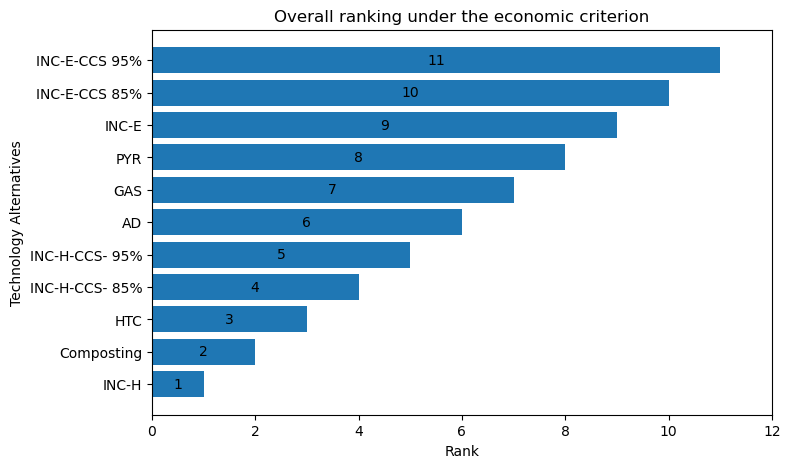

In [17]:
import matplotlib.pyplot as plt

plot_data = final_ranking.sort_values("Rank", ascending=False)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["Alternative"],
    plot_data["Rank"]
)

plt.xlabel("Rank")
plt.ylabel("Technology Alternatives")
plt.title("Overall ranking under the economic criterion")

for index, row in plot_data.iterrows():
    plt.text(
        row["Rank"] / 2,
        row["Alternative"],
        int(row["Rank"]),
        va="center",
        ha="center"
    )

plt.xlim(0, final_ranking["Rank"].max() + 1)
plt.gca().invert_yaxis()

plt.show()

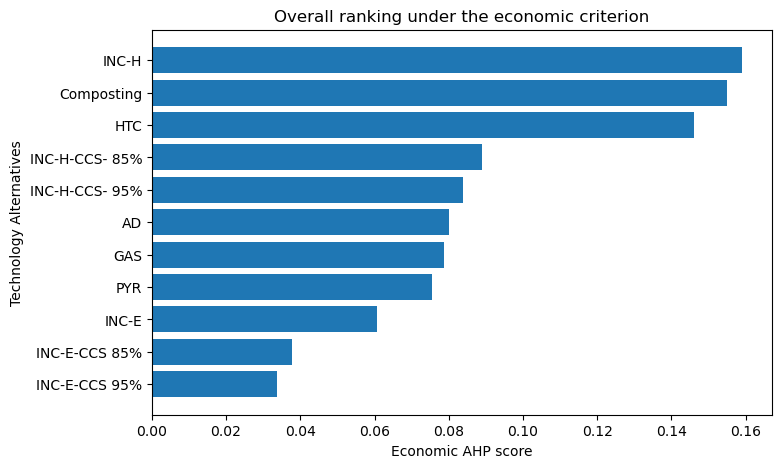

In [18]:
import matplotlib.pyplot as plt

plot_data = final_ranking.sort_values("Economic_AHP_score", ascending=True)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["Alternative"],
    plot_data["Economic_AHP_score"]
)

plt.xlabel("Economic AHP score")
plt.ylabel("Technology Alternatives")
plt.title("Overall ranking under the economic criterion")

plt.show()